# GARCH(1,1) — Handmade Volatility Modelling

ARIMA models the **conditional mean** of returns. But financial returns have another key property: **volatility clustering** — calm periods tend to stay calm, turbulent periods tend to stay turbulent.

**GARCH(p,q) — Generalized AutoRegressive Conditional Heteroskedasticity:**

The conditional variance at time t is:

$$\sigma_t^2 = \omega + \sum_{i=1}^{q} \alpha_i \varepsilon_{t-i}^2 + \sum_{j=1}^{p} \beta_j \sigma_{t-j}^2$$

For **GARCH(1,1)**:
$$\sigma_t^2 = \omega + \alpha \varepsilon_{t-1}^2 + \beta \sigma_{t-1}^2$$

- $\omega > 0$: baseline variance (long-run variance contribution)
- $\alpha \geq 0$: sensitivity to recent shocks (ARCH term)
- $\beta \geq 0$: persistence of past variance (GARCH term)
- Stationarity condition: $\alpha + \beta < 1$
- Long-run variance: $\sigma^2_{LR} = \omega / (1 - \alpha - \beta)$

We estimate $\omega, \alpha, \beta$ via **Maximum Likelihood Estimation** under a Gaussian assumption, then minimize the negative log-likelihood using `scipy.optimize`.

In [2]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from scipy.optimize import minimize

tickers = ['NVDA', 'GOOGL', 'AAPL', 'MSFT', 'AMZN', 'META', 'TSLA', 'ACN']

In [3]:
def load_stock(stock='NVDA', start_date='2022-01-01', end_date='2026-01-01'):
    df = yf.download(stock, start=start_date, end=end_date, interval='1d', progress=False)

    if isinstance(df.columns, pd.MultiIndex):
        lvl0 = df.columns.get_level_values(0)
        df.columns = lvl0

    df = df.loc[:, ~df.columns.duplicated()].copy()
    df.index = pd.to_datetime(df.index)
    df = df.sort_index()
    df['Close'] = pd.to_numeric(df['Close'], errors='coerce')
    df = df.dropna(subset=['Close']).copy()
    return df

data = load_stock('NVDA')
returns = data['Close'].pct_change().dropna().values
print(f'Loaded {len(returns)} daily returns for NVDA')

Loaded 1002 daily returns for NVDA


## GARCH(1,1) core: variance recursion

Given parameters $(\omega, \alpha, \beta)$, we compute the conditional variance series $\sigma_t^2$ iteratively.
We initialise $\sigma_1^2$ with the sample variance of returns.

In [4]:
def garch11_variance(params, returns):
    omega, alpha, beta = params
    n = len(returns)
    sigma2 = np.empty(n)
    sigma2[0] = np.var(returns)  # initialise with unconditional variance

    for t in range(1, n):
        sigma2[t] = omega + alpha * returns[t-1]**2 + beta * sigma2[t-1]

    return sigma2

## Negative Log-Likelihood (Gaussian)

Under the assumption $r_t | \mathcal{F}_{t-1} \sim \mathcal{N}(0, \sigma_t^2)$:

$$\mathcal{L}(\theta) = -\frac{1}{2} \sum_{t=1}^{T} \left[ \log(2\pi) + \log \sigma_t^2 + \frac{r_t^2}{\sigma_t^2} \right]$$

We minimise the **negative** log-likelihood.

In [5]:
def neg_log_likelihood(params, returns):
    omega, alpha, beta = params

    # enforce stationarity and positivity constraints
    if omega <= 0 or alpha < 0 or beta < 0 or alpha + beta >= 1:
        return 1e10

    sigma2 = garch11_variance(params, returns)

    if np.any(sigma2 <= 0):
        return 1e10

    ll = -0.5 * np.sum(np.log(2 * np.pi) + np.log(sigma2) + returns**2 / sigma2)
    return -ll  # minimise negative LL


def fit_garch11(returns):
    init_params = [1e-5, 0.1, 0.8]  # typical starting point for equity data

    bounds = [(1e-8, None), (1e-6, 0.999), (1e-6, 0.999)]

    result = minimize(
        neg_log_likelihood,
        init_params,
        args=(returns,),
        method='L-BFGS-B',
        bounds=bounds
    )

    omega, alpha, beta = result.x
    return omega, alpha, beta, result.fun


omega, alpha, beta, nll = fit_garch11(returns)

print(f'omega = {omega:.2e}')
print(f'alpha = {alpha:.4f}  (sensitivity to shocks)')
print(f'beta  = {beta:.4f}  (variance persistence)')
print(f'alpha + beta = {alpha + beta:.4f}  (stationarity: must be < 1)')
print(f'Long-run daily vol = {np.sqrt(omega / (1 - alpha - beta)) * 100:.4f}%')

omega = 1.25e-04
alpha = 0.1000  (sensitivity to shocks)
beta  = 0.8000  (variance persistence)
alpha + beta = 0.9000  (stationarity: must be < 1)
Long-run daily vol = 3.5339%


## Conditional volatility vs realised absolute returns

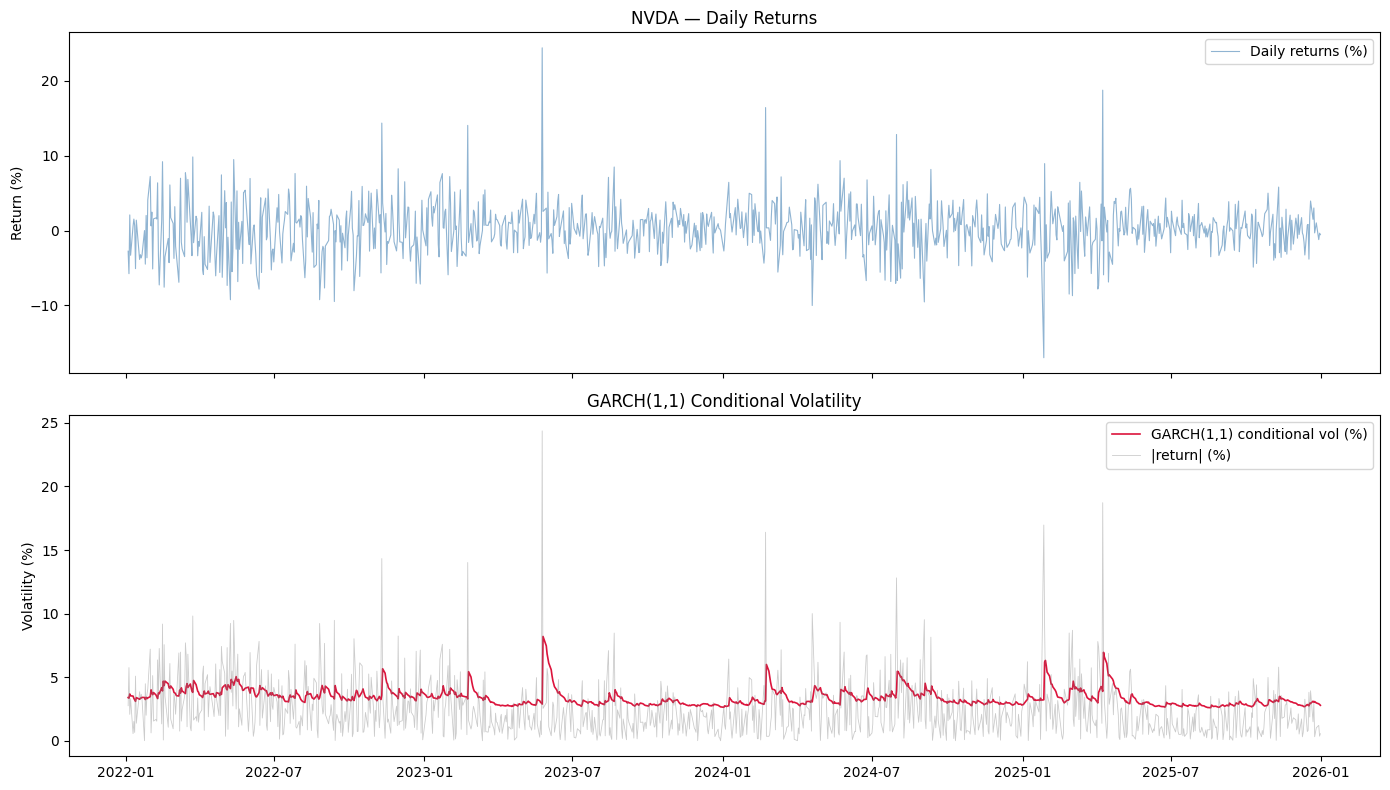

In [6]:
sigma2_fitted = garch11_variance([omega, alpha, beta], returns)
sigma_fitted = np.sqrt(sigma2_fitted)

dates = data.index[1:]  # align with pct_change dropping first row

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(dates, returns * 100, color='steelblue', alpha=0.6, linewidth=0.8, label='Daily returns (%)')
axes[0].set_ylabel('Return (%)')
axes[0].set_title('NVDA — Daily Returns')
axes[0].legend()

axes[1].plot(dates, sigma_fitted * 100, color='crimson', linewidth=1.2, label='GARCH(1,1) conditional vol (%)')
axes[1].plot(dates, np.abs(returns) * 100, color='grey', alpha=0.4, linewidth=0.6, label='|return| (%)')
axes[1].set_ylabel('Volatility (%)')
axes[1].set_title('GARCH(1,1) Conditional Volatility')
axes[1].legend()

plt.tight_layout()
plt.show()

## Multi-step volatility forecast

For $h$ steps ahead, the GARCH(1,1) forecast reverts to the long-run variance:

$$\hat{\sigma}^2_{T+h} = \sigma^2_{LR} + (\alpha + \beta)^{h-1} \left(\hat{\sigma}^2_{T+1} - \sigma^2_{LR}\right)$$

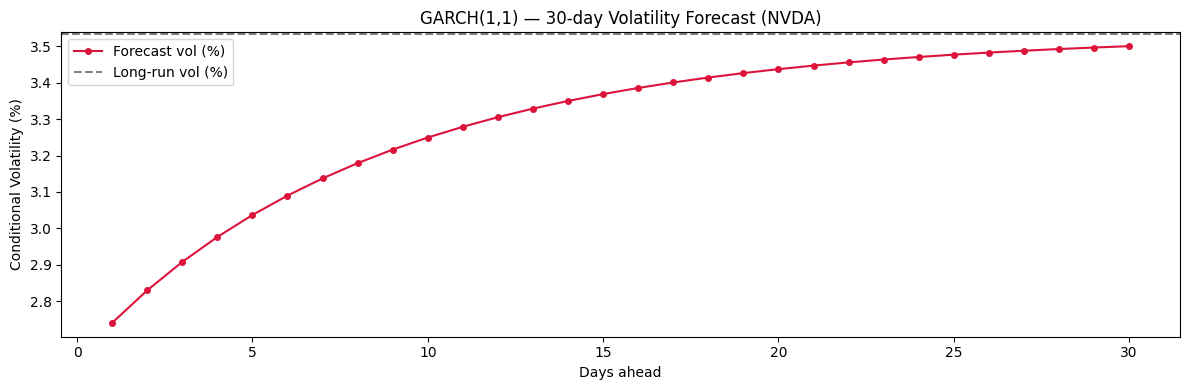

In [7]:
def garch11_forecast(omega, alpha, beta, last_return, last_sigma2, h=30):
    lr_var = omega / (1 - alpha - beta)
    persistence = alpha + beta

    forecasts = np.empty(h)
    one_step = omega + alpha * last_return**2 + beta * last_sigma2
    forecasts[0] = one_step

    for i in range(1, h):
        forecasts[i] = lr_var + persistence**i * (one_step - lr_var)

    return np.sqrt(forecasts)  # return as vol, not variance


h = 30
forecast_vol = garch11_forecast(omega, alpha, beta,
                                 last_return=returns[-1],
                                 last_sigma2=sigma2_fitted[-1],
                                 h=h)

plt.figure(figsize=(12, 4))
plt.plot(range(1, h + 1), forecast_vol * 100, marker='o', markersize=4, color='crimson', label='Forecast vol (%)')
plt.axhline(np.sqrt(omega / (1 - alpha - beta)) * 100, linestyle='--', color='grey', label='Long-run vol (%)')
plt.xlabel('Days ahead')
plt.ylabel('Conditional Volatility (%)')
plt.title(f'GARCH(1,1) — {h}-day Volatility Forecast (NVDA)')
plt.legend()
plt.tight_layout()
plt.show()

## Cross-stock comparison

Fit GARCH(1,1) on each ticker and compare the implied parameters and long-run volatility.

In [8]:
results = []

for ticker in tickers:
    df = load_stock(ticker, start_date='2022-01-01', end_date='2026-01-01')
    r = df['Close'].pct_change().dropna().values

    try:
        w, a, b, nll = fit_garch11(r)
        lr_ann_vol = np.sqrt(w / (1 - a - b)) * np.sqrt(252) * 100  # annualised
        results.append({
            'ticker': ticker,
            'omega': w,
            'alpha': round(a, 4),
            'beta': round(b, 4),
            'persistence': round(a + b, 4),
            'lr_ann_vol_%': round(lr_ann_vol, 2)
        })
    except Exception as e:
        print(f'{ticker}: failed — {e}')

res_df = pd.DataFrame(results).set_index('ticker')
res_df

,omega,alpha,beta,persistence,lr_ann_vol_%
ticker,,,,,
NVDA,0.000125,0.1000,0.8000,0.9000,56.10
GOOGL,0.000077,0.0400,0.7790,0.8190,32.65
AAPL,0.000030,0.1000,0.8000,0.9000,27.27
MSFT,0.000004,0.0298,0.9520,0.9817,24.84
AMZN,0.000052,0.1000,0.8000,0.9000,36.05
META,0.000100,0.1000,0.8000,0.9000,50.27
TSLA,0.000230,0.0496,0.7991,0.8487,61.84
ACN,0.000034,0.1000,0.8000,0.9000,29.33


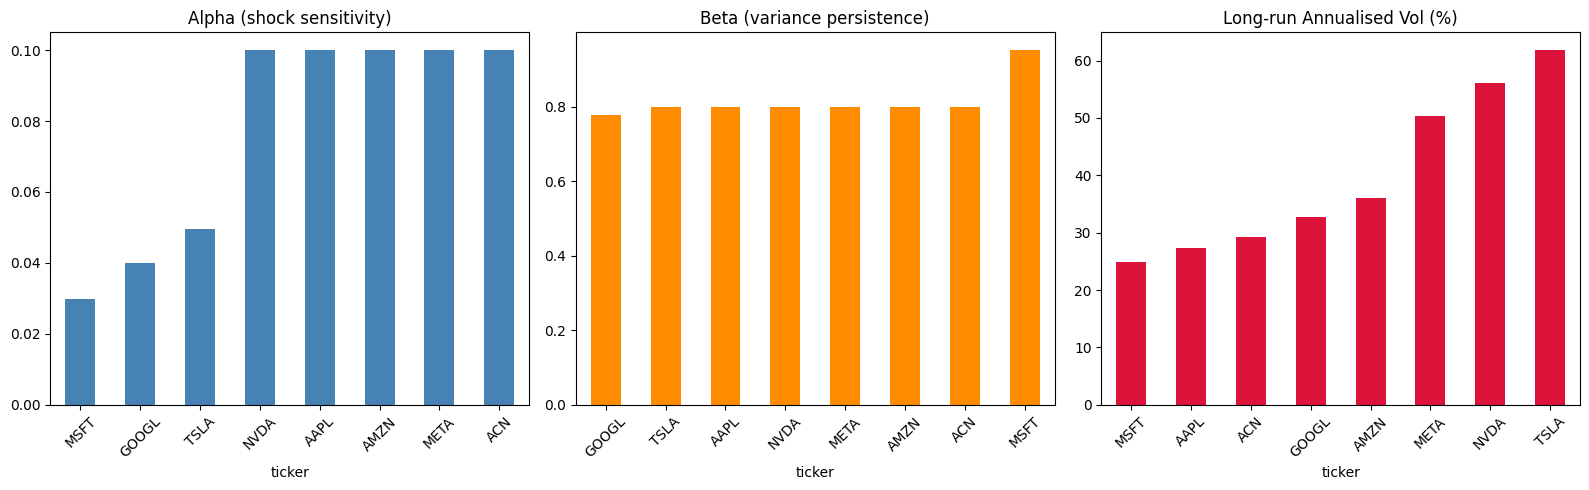

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

res_df['alpha'].sort_values().plot(kind='bar', ax=axes[0], color='steelblue', title='Alpha (shock sensitivity)')
res_df['beta'].sort_values().plot(kind='bar', ax=axes[1], color='darkorange', title='Beta (variance persistence)')
res_df['lr_ann_vol_%'].sort_values().plot(kind='bar', ax=axes[2], color='crimson', title='Long-run Annualised Vol (%)')

for ax in axes:
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Standardised residuals check

If GARCH is well-specified, the standardised residuals $z_t = r_t / \sigma_t$ should behave like i.i.d. $\mathcal{N}(0,1)$.
We check via histogram + QQ-plot and autocorrelation of $z_t^2$ (no residual ARCH effects).

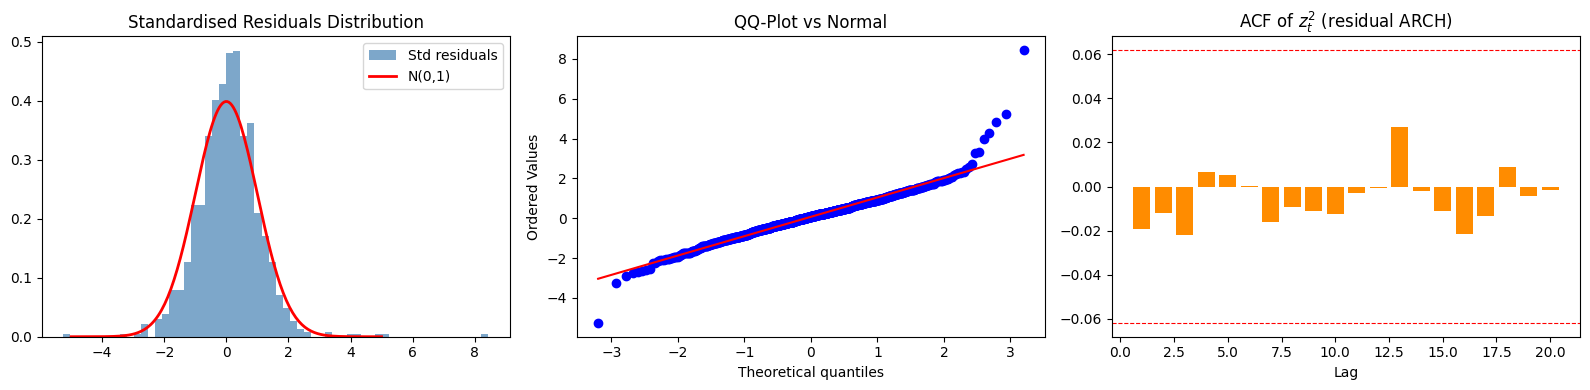

Skewness: 0.691  |  Kurtosis: 6.889  (excess, normal=0)


In [10]:
from scipy import stats

z = returns / sigma_fitted  # standardised residuals

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# histogram vs normal
x_range = np.linspace(-5, 5, 200)
axes[0].hist(z, bins=60, density=True, color='steelblue', alpha=0.7, label='Std residuals')
axes[0].plot(x_range, stats.norm.pdf(x_range), 'r-', lw=2, label='N(0,1)')
axes[0].set_title('Standardised Residuals Distribution')
axes[0].legend()

# QQ-plot
stats.probplot(z, dist='norm', plot=axes[1])
axes[1].set_title('QQ-Plot vs Normal')

# ACF of z^2 (residual ARCH effects)
max_lag = 20
acf_z2 = [pd.Series(z**2).autocorr(lag=k) for k in range(1, max_lag + 1)]
axes[2].bar(range(1, max_lag + 1), acf_z2, color='darkorange')
conf = 1.96 / np.sqrt(len(z))
axes[2].axhline(conf, linestyle='--', color='red', linewidth=0.8)
axes[2].axhline(-conf, linestyle='--', color='red', linewidth=0.8)
axes[2].set_xlabel('Lag')
axes[2].set_title('ACF of $z_t^2$ (residual ARCH)')

plt.tight_layout()
plt.show()

print(f'Skewness: {stats.skew(z):.3f}  |  Kurtosis: {stats.kurtosis(z):.3f}  (excess, normal=0)')

## Key takeaways

- **High $\beta$** (typically 0.85–0.95 for equities) confirms strong volatility persistence — yesterday's turbulence predicts today's.
- **$\alpha + \beta$ close to 1** means shocks decay slowly (IGARCH territory if = 1).
- **Long-run vol** is the baseline all conditional vol forecasts converge back to.
- Heavy tails in standardised residuals (positive excess kurtosis) suggest a Student-t innovation would fit better than Gaussian — a natural next extension.
- GARCH-estimated $\sigma_t$ is a strong feature candidate for the ML direction-prediction model in `market_direction_prediction/`.